In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

nav = pd.read_csv("../data/processed/cleaned_nav_history.csv")

print(nav.head())
print(nav.shape)
import os
print(os.getcwd())

   amfi_code        date       nav
0     100016  2022-01-03  520.4608
1     100016  2022-01-04  515.0971
2     100016  2022-01-05  521.7239
3     100016  2022-01-06  515.7880
4     100016  2022-01-07  515.1639
(46000, 3)
c:\Users\acer\bluestock_mf_capstone\notebooks


In [4]:
# Convert date column to datetime
nav["date"] = pd.to_datetime(nav["date"])

# Sort data
nav = nav.sort_values(["amfi_code", "date"])

# Calculate daily return
nav["daily_return"] = nav.groupby("amfi_code")["nav"].pct_change()

# View results
print(nav.head(10))

# Summary statistics
print("\nDaily Return Summary:")
print(nav["daily_return"].describe())

   amfi_code       date       nav  daily_return
0     100016 2022-01-03  520.4608           NaN
1     100016 2022-01-04  515.0971     -0.010306
2     100016 2022-01-05  521.7239      0.012865
3     100016 2022-01-06  515.7880     -0.011377
4     100016 2022-01-07  515.1639     -0.001210
5     100016 2022-01-10  510.7136     -0.008639
6     100016 2022-01-11  513.5542      0.005562
7     100016 2022-01-12  512.3195     -0.002404
8     100016 2022-01-13  510.2445     -0.004050
9     100016 2022-01-14  514.3636      0.008073

Daily Return Summary:
count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64


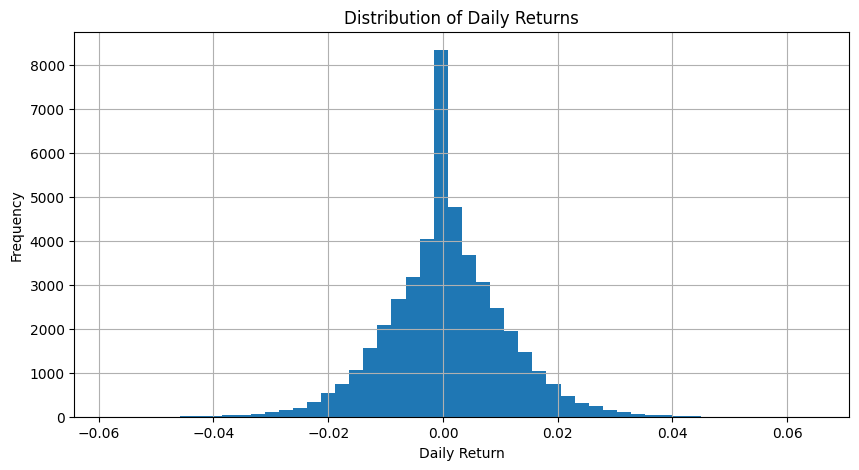

In [5]:
plt.figure(figsize=(10,5))
nav["daily_return"].dropna().hist(bins=50)

plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.show()

In [6]:
# CAGR Calculation

cagr_results = []

for fund in nav["amfi_code"].unique():

    fund_data = nav[nav["amfi_code"] == fund].sort_values("date")

    nav_start = fund_data["nav"].iloc[0]
    nav_end = fund_data["nav"].iloc[-1]

    years = (
        (fund_data["date"].max() - fund_data["date"].min()).days
        / 365.25
    )

    cagr = ((nav_end / nav_start) ** (1 / years) - 1) * 100

    cagr_results.append([fund, cagr])

cagr_df = pd.DataFrame(
    cagr_results,
    columns=["amfi_code", "cagr_pct"]
)

cagr_df = cagr_df.sort_values(
    "cagr_pct",
    ascending=False
)

print(cagr_df.head(10))

    amfi_code   cagr_pct
25     120505  32.827406
21     119598  32.423536
39     149324  32.287440
36     148569  31.949523
34     148567  30.974108
30     120843  30.907455
2      100033  30.123153
38     149323  29.581087
16     119094  28.214417
19     119551  25.804686


In [7]:
cagr_df.to_csv(
    "../data/processed/cagr_results.csv",
    index=False
)

print("CAGR file saved successfully")

CAGR file saved successfully


In [8]:
# Risk-free rate
rf = 0.065

sharpe_results = []

for fund in nav["amfi_code"].unique():

    fund_returns = nav.loc[
        nav["amfi_code"] == fund,
        "daily_return"
    ].dropna()

    if len(fund_returns) > 0:

        annual_return = fund_returns.mean() * 252
        annual_volatility = fund_returns.std() * np.sqrt(252)

        sharpe = (
            (annual_return - rf)
            / annual_volatility
        )

        sharpe_results.append(
            [fund, sharpe]
        )

sharpe_df = pd.DataFrame(
    sharpe_results,
    columns=["amfi_code", "sharpe_ratio"]
)

sharpe_df = sharpe_df.sort_values(
    "sharpe_ratio",
    ascending=False
)

print(sharpe_df.head(10))

    amfi_code  sharpe_ratio
34     148567      1.448291
30     120843      1.306744
36     148569      1.234930
19     119551      1.208267
25     120505      1.180101
38     149323      1.132122
2      100033      1.093699
9      118632      1.081659
3      101206      1.027213
24     120504      1.026524


In [9]:
sharpe_df.to_csv(
    "../data/processed/sharpe_ratio.csv",
    index=False
)

print("Sharpe Ratio file saved")

Sharpe Ratio file saved


In [10]:
# Sortino Ratio

rf = 0.065

sortino_results = []

for fund in nav["amfi_code"].unique():

    returns = nav.loc[
        nav["amfi_code"] == fund,
        "daily_return"
    ].dropna()

    downside_returns = returns[returns < 0]

    if len(downside_returns) > 0:

        annual_return = returns.mean() * 252

        downside_std = (
            downside_returns.std()
            * np.sqrt(252)
        )

        sortino = (
            (annual_return - rf)
            / downside_std
        )

        sortino_results.append(
            [fund, sortino]
        )

sortino_df = pd.DataFrame(
    sortino_results,
    columns=["amfi_code", "sortino_ratio"]
)

sortino_df = sortino_df.sort_values(
    "sortino_ratio",
    ascending=False
)

print(sortino_df.head(10))

    amfi_code  sortino_ratio
34     148567       2.385644
30     120843       2.364320
36     148569       2.146914
19     119551       2.140267
25     120505       2.029353
38     149323       1.875101
9      118632       1.850133
2      100033       1.829134
24     120504       1.805294
3      101206       1.799563


In [11]:
sortino_df.to_csv(
    "../data/processed/sortino_ratio.csv",
    index=False
)

print("Sortino Ratio file saved")

Sortino Ratio file saved


In [12]:
# Load benchmark data

benchmark = pd.read_csv(
    "../data/raw/10_benchmark_indices.csv"
)

benchmark["date"] = pd.to_datetime(
    benchmark["date"]
)

# Use NIFTY100 benchmark
nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

nifty100 = nifty100.sort_values("date")

nifty100["benchmark_return"] = (
    nifty100["close_value"].pct_change()
)

alpha_beta_results = []

for fund in nav["amfi_code"].unique():

    fund_data = nav[
        ["date", "amfi_code", "daily_return"]
    ]

    fund_data = fund_data[
        fund_data["amfi_code"] == fund
    ]

    merged = pd.merge(
        fund_data,
        nifty100[["date", "benchmark_return"]],
        on="date",
        how="inner"
    )

    merged = merged.dropna()

    if len(merged) > 30:

        slope, intercept, r, p, std = (
            stats.linregress(
                merged["benchmark_return"],
                merged["daily_return"]
            )
        )

        beta = slope
        alpha = intercept * 252

        alpha_beta_results.append(
            [fund, alpha, beta]
        )

alpha_beta_df = pd.DataFrame(
    alpha_beta_results,
    columns=[
        "amfi_code",
        "alpha",
        "beta"
    ]
)

print(alpha_beta_df.head())

   amfi_code     alpha      beta
0     100016  0.037476 -0.058268
1     100025  0.042818  0.001158
2     100033  0.271954  0.005104
3     101206  0.213998  0.021086
4     101207  0.108971 -0.065289


In [13]:
alpha_beta_df.to_csv(
    "../data/processed/alpha_beta.csv",
    index=False
)

print("alpha_beta.csv saved")

alpha_beta.csv saved


In [14]:
# Maximum Drawdown

mdd_results = []

for fund in nav["amfi_code"].unique():

    fund_data = nav[
        nav["amfi_code"] == fund
    ].sort_values("date")

    running_max = fund_data["nav"].cummax()

    drawdown = (
        fund_data["nav"] / running_max
    ) - 1

    max_drawdown = drawdown.min()

    mdd_results.append(
        [fund, max_drawdown]
    )

mdd_df = pd.DataFrame(
    mdd_results,
    columns=[
        "amfi_code",
        "max_drawdown"
    ]
)

print(mdd_df.head())

   amfi_code  max_drawdown
0     100016     -0.247344
1     100025     -0.043083
2     100033     -0.162172
3     101206     -0.112916
4     101207     -0.354469


In [15]:
# Fund Scorecard

scorecard = cagr_df.merge(
    sharpe_df,
    on="amfi_code"
)

scorecard = scorecard.merge(
    alpha_beta_df,
    on="amfi_code"
)

scorecard = scorecard.merge(
    mdd_df,
    on="amfi_code"
)

# Rank metrics
scorecard["return_rank"] = scorecard["cagr_pct"].rank(
    ascending=False
)

scorecard["sharpe_rank"] = scorecard["sharpe_ratio"].rank(
    ascending=False
)

scorecard["alpha_rank"] = scorecard["alpha"].rank(
    ascending=False
)

scorecard["mdd_rank"] = scorecard["max_drawdown"].rank(
    ascending=False
)

# Composite Score
scorecard["fund_score"] = (
    scorecard["return_rank"] * 0.30 +
    scorecard["sharpe_rank"] * 0.25 +
    scorecard["alpha_rank"] * 0.20 +
    scorecard["mdd_rank"] * 0.10
)

scorecard = scorecard.sort_values(
    "fund_score"
)

print(scorecard.head(10))

    amfi_code   cagr_pct  sharpe_ratio     alpha      beta  max_drawdown  \
4      148567  30.974108      1.448291  0.269838  0.023684     -0.112657   
5      120843  30.907455      1.306744  0.273305 -0.022830     -0.129740   
0      120505  32.827406      1.180101  0.292636  0.000549     -0.181885   
3      148569  31.949523      1.234930  0.282704  0.018134     -0.163967   
6      100033  30.123153      1.093699  0.271954  0.005104     -0.162172   
7      149323  29.581087      1.132122  0.265986 -0.002523     -0.172481   
9      119551  25.804686      1.208267  0.232010 -0.031751     -0.150124   
1      119598  32.423536      0.945308  0.303370 -0.023196     -0.287060   
2      149324  32.287440      0.949796  0.300579  0.011455     -0.311719   
11     101206  23.538361      1.027213  0.213998  0.021086     -0.112916   

    return_rank  sharpe_rank  alpha_rank  mdd_rank  fund_score  
4           5.0          1.0         7.0       8.0        3.95  
5           6.0          2.0     

In [16]:
scorecard.to_csv(
    "../data/processed/fund_scorecard.csv",
    index=False
)

print("fund_scorecard.csv saved")

fund_scorecard.csv saved


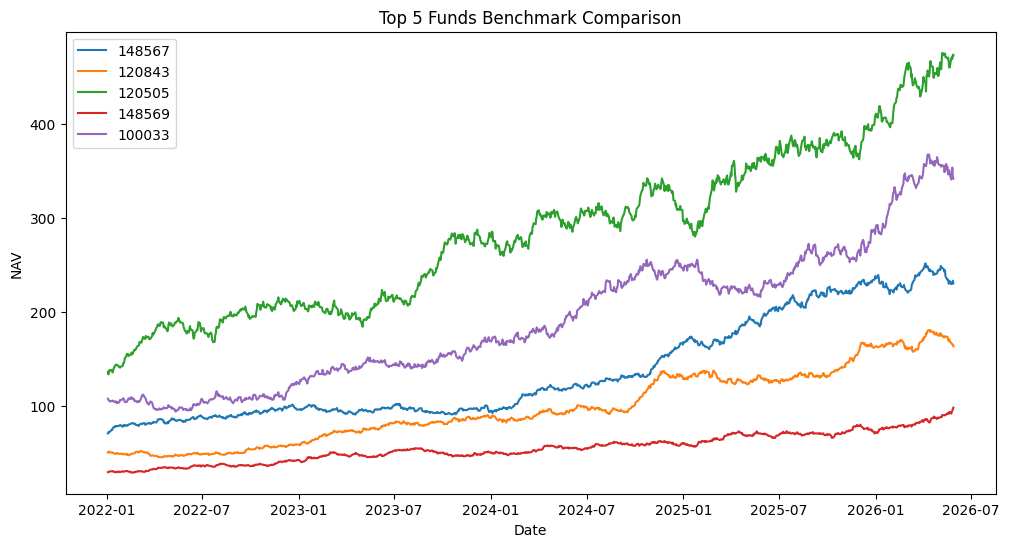

benchmark_comparison.png saved


In [17]:
plt.figure(figsize=(12,6))

top5 = scorecard.head(5)["amfi_code"]

for fund in top5:

    fund_data = nav[
        nav["amfi_code"] == fund
    ]

    plt.plot(
        fund_data["date"],
        fund_data["nav"],
        label=str(fund)
    )

plt.legend()
plt.title("Top 5 Funds Benchmark Comparison")
plt.xlabel("Date")
plt.ylabel("NAV")

plt.savefig(
    "../data/processed/benchmark_comparison.png"
)

plt.show()

print("benchmark_comparison.png saved")

In [18]:
perf = pd.read_csv("../data/raw/07_scheme_performance.csv")

print(perf.columns.tolist())

['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct', 'morningstar_rating', 'risk_grade']


In [19]:
cagr_comparison = perf[
    [
        "amfi_code",
        "scheme_name",
        "return_1yr_pct",
        "return_3yr_pct",
        "return_5yr_pct"
    ]
]

print(cagr_comparison.head())

cagr_comparison.to_csv(
    "../data/processed/cagr_comparison_table.csv",
    index=False
)

print("cagr_comparison_table.csv saved")

   amfi_code                                   scheme_name  return_1yr_pct  \
0     119551     SBI Bluechip Fund - Regular Plan - Growth           12.42   
1     119552      SBI Bluechip Fund - Direct Plan - Growth           15.25   
2     119598    SBI Small Cap Fund - Regular Plan - Growth           24.56   
3     119599     SBI Small Cap Fund - Direct Plan - Growth           20.59   
4     119120  SBI Magnum Gilt Fund - Regular Plan - Growth            5.34   

   return_3yr_pct  return_5yr_pct  
0           12.36           14.45  
1           11.30           14.23  
2           23.39           20.67  
3           23.14           21.82  
4            6.07            5.43  
cagr_comparison_table.csv saved


In [20]:
drawdown_ranges = []

for fund in nav["amfi_code"].unique():

    fund_data = nav[
        nav["amfi_code"] == fund
    ].sort_values("date")

    running_max = fund_data["nav"].cummax()

    drawdown = (
        fund_data["nav"] / running_max
    ) - 1

    worst_idx = drawdown.idxmin()

    worst_date = fund_data.loc[
        worst_idx,
        "date"
    ]

    drawdown_ranges.append(
        [fund, drawdown.min(), worst_date]
    )

drawdown_range_df = pd.DataFrame(
    drawdown_ranges,
    columns=[
        "amfi_code",
        "max_drawdown",
        "worst_drawdown_date"
    ]
)

print(drawdown_range_df.head())

drawdown_range_df.to_csv(
    "../data/processed/drawdown_ranges.csv",
    index=False
)

print("drawdown_ranges.csv saved")

   amfi_code  max_drawdown worst_drawdown_date
0     100016     -0.247344          2022-09-15
1     100025     -0.043083          2023-07-28
2     100033     -0.162172          2022-05-12
3     101206     -0.112916          2023-07-05
4     101207     -0.354469          2026-05-11
drawdown_ranges.csv saved


In [21]:
scorecard = perf[
    [
        "amfi_code",
        "scheme_name",
        "return_3yr_pct",
        "expense_ratio_pct"
    ]
].copy()

scorecard = scorecard.merge(
    sharpe_df,
    on="amfi_code"
)

scorecard = scorecard.merge(
    alpha_beta_df,
    on="amfi_code"
)

scorecard = scorecard.merge(
    mdd_df,
    on="amfi_code"
)

scorecard["return_rank"] = scorecard[
    "return_3yr_pct"
].rank(ascending=False)

scorecard["sharpe_rank"] = scorecard[
    "sharpe_ratio"
].rank(ascending=False)

scorecard["alpha_rank"] = scorecard[
    "alpha"
].rank(ascending=False)

scorecard["expense_rank"] = scorecard[
    "expense_ratio_pct"
].rank(ascending=True)

scorecard["mdd_rank"] = scorecard[
    "max_drawdown"
].rank(ascending=False)

scorecard["fund_score"] = (
    scorecard["return_rank"] * 0.30 +
    scorecard["sharpe_rank"] * 0.25 +
    scorecard["alpha_rank"] * 0.20 +
    scorecard["expense_rank"] * 0.15 +
    scorecard["mdd_rank"] * 0.10
)

scorecard = scorecard.sort_values(
    "fund_score"
)

print(scorecard.head())

scorecard.to_csv(
    "../data/processed/fund_scorecard.csv",
    index=False
)

print("Updated fund_scorecard.csv saved")

    amfi_code                                        scheme_name  \
12     120505           ICICI Pru Midcap Fund - Regular - Growth   
22     120843             Kotak Flexicap Fund - Regular - Growth   
7      100033  HDFC Mid-Cap Opportunities Fund - Regular - Gr...   
2      119598         SBI Small Cap Fund - Regular Plan - Growth   
34     148567      Mirae Asset Large Cap Fund - Regular - Growth   

    return_3yr_pct  expense_ratio_pct  sharpe_ratio     alpha      beta  \
12           18.08               1.36      1.180101  0.292636  0.000549   
22           15.65               1.45      1.306744  0.273305 -0.022830   
7            16.58               1.38      1.093699  0.271954  0.005104   
2            23.39               1.43      0.945308  0.303370 -0.023196   
34           14.81               1.46      1.448291  0.269838  0.023684   

    max_drawdown  return_rank  sharpe_rank  alpha_rank  expense_rank  \
12     -0.181885          8.0          5.0         3.0          15.0

In [22]:
tracking_errors = []

for fund in nav["amfi_code"].unique():

    fund_data = nav[
        nav["amfi_code"] == fund
    ][["date", "daily_return"]]

    merged = pd.merge(
        fund_data,
        nifty100[["date", "benchmark_return"]],
        on="date",
        how="inner"
    )

    merged = merged.dropna()

    if len(merged) > 30:

        tracking_error = (
            (merged["daily_return"] -
             merged["benchmark_return"]).std()
            * np.sqrt(252)
        )

        tracking_errors.append(
            [fund, tracking_error]
        )

tracking_error_df = pd.DataFrame(
    tracking_errors,
    columns=[
        "amfi_code",
        "tracking_error"
    ]
)

print(tracking_error_df.head())

tracking_error_df.to_csv(
    "../data/processed/tracking_error.csv",
    index=False
)

print("tracking_error.csv saved")

   amfi_code  tracking_error
0     100016        0.199284
1     100025        0.134535
2     100033        0.228699
3     101206        0.192706
4     101207        0.292117
tracking_error.csv saved


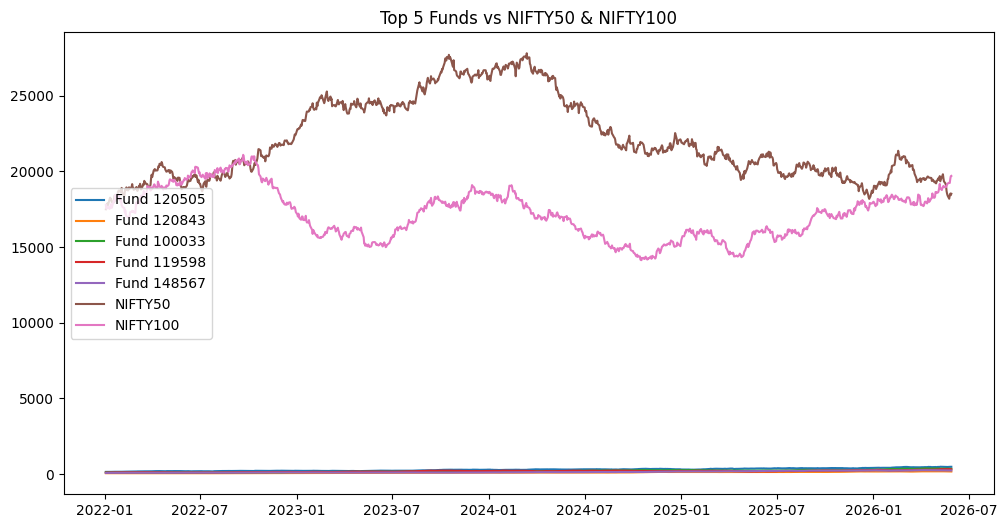

Updated benchmark_comparison.png saved


In [23]:
nifty50 = benchmark[
    benchmark["index_name"] == "NIFTY50"
]

plt.figure(figsize=(12,6))

top5 = scorecard.head(5)["amfi_code"]

for fund in top5:

    fund_data = nav[
        nav["amfi_code"] == fund
    ]

    plt.plot(
        fund_data["date"],
        fund_data["nav"],
        label=f"Fund {fund}"
    )

plt.plot(
    nifty50["date"],
    nifty50["close_value"],
    label="NIFTY50"
)

plt.plot(
    nifty100["date"],
    nifty100["close_value"],
    label="NIFTY100"
)

plt.legend()

plt.title(
    "Top 5 Funds vs NIFTY50 & NIFTY100"
)

plt.savefig(
    "../data/processed/benchmark_comparison.png"
)

plt.show()

print("Updated benchmark_comparison.png saved")